# 💡 Thuật toán Linear Regression - Linear Fitting - Linear Least Square
## ☕ Ý tưởng cốt lõi
- Tìm mối quan hệ giữa đầu vào và đầu ra bởi một hàm tuyến tính:

  $$y \approx \hat{y} = f(\mathbf{x}) = w_1 x_1 + w_2 x_2 + w_3 x_3 = \mathbf{x}^T \mathbf{w}$$

- Trong không gian hai chiều hàm số là một đường thẳng
- Trong không gian ba chiều hàm số là một mặt phẳng
- Trong không gian N chiều hàm số là một siêu phẳng (hyperplane)

## ❗ Lưu ý:
- Hàm số trên tuyến tính cả với $\mathbf{x}$ và $\mathbf{w}$
- Thuật toán nhạy cảm với nhiễu, outlier cần pre-processing data
- Thuật toán không biểu diễn được các mô hình có mối quan hệ phức tạp
- Ngoài ra có thể sử dụng **Huber Loss** để tối ưu các nghiệm nhiễu




# ☕ Phân tích toán học & Tối ưu tính toán

- Tập dữ liệu train: $X \in \mathbb{R}^{N \times d}$ trong đó $x_i \in \mathbb{R}^{d}$
- Trọng số - weight: $W \in \mathbb{R}^{d}$
- Target: $y \in \mathbb{R}^{N}$

## ⚡ Hàm mất mát:

$$L(\mathbf{w}) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - \mathbf{x}_i^T \mathbf{w})^2 =  \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2$$

$$\mathbf{w}^* = \arg\min_{\mathbf{w}} L(\mathbf{w}) $$

## ⚡ Giải nghiệm cho bài toán:

### ♒ Phương pháp tìm nghiệm trực tiếp

- Nhận thấy hàm $L(w)$ có đạo hàm nên ta có thể giải nghiệm trực tiếp:

  $$\frac{\partial L(\mathbf{w})}{\partial \mathbf{w}} = \frac{1}{N} \mathbf{X^T} (\mathbf{X}\mathbf{w} - \mathbf{y})$$
- Giải phương trình đạo hàm bằng 0 ta có:

  $$\frac{\partial L(\mathbf{w})}{\partial \mathbf{w}} = 0 ⇔ \mathbf{X^T} \mathbf{X}\mathbf{w} = \mathbf{X^T}\mathbf{y}  $$

  - Nếu ma trận $\mathbf{X^TX}$ khả nghịch thì sẽ có nghiệm:

      $$\mathbf{w} = (\mathbf{X^TX})^{-1}\mathbf{X^Ty} $$

  - Nếu ma trận $\mathbf{X^TX}$ không khả nghịch thì sẽ có vố số nghiệm hoặc vô nghiệm, lúc này muốn tìm nghiệm đặc biệt (nghiệm giúp tối thiểu norm $l_2$) của phương trình ta dựa vào **giả nghịch đảo**:

    $$ \mathbf{w} = (\mathbf{X^TX})^{†}\mathbf{X^Ty} $$

- Bias Trick - thêm 1 vào vector đặc trưng:

  $$y = \mathbf{x}^T \mathbf{w} + b = \bar{\mathbf{x}}^T \bar{\mathbf{w}}$$

  $$\text{Với } x_0 = 1, \quad \bar{\mathbf{x}} = \begin{bmatrix} x_0 \\ x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix} = \begin{bmatrix} 1 \\ x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}, \quad \text{và } \bar{\mathbf{w}} = \begin{bmatrix} b \\ w_1 \\ w_2 \\ \vdots \\ w_d \end{bmatrix}$$
  
  - Hệ số bias $\mathbf{b}$ giúp hàm số tránh bị ràng buộc luôn phải đi qua gốc tọa độ

  $$\bar{\mathbf{w}}^* = \arg\min_{\bar{\mathbf{w}}} \frac{1}{2N} \|\mathbf{y} - \mathbf{\bar{X}} \bar{\mathbf{w}}\|_2^2 = (\mathbf{\bar{X}^T} \mathbf{\bar{X}})^{\dagger} \mathbf{\bar{X}^T} \mathbf{y}$$

#### ⛪ Ridge Regression

- Trong trường hợp $\mathbf{X^TX}$ không khả nghịch, có một kỹ thuật nhỏ có thể áp dụng để tránh hiện tượng không khả nghịch này là biến đổi $\mathbf{X^TX}$ thành $\mathbf{A} = \mathbf{X^TX} + λ\mathbf{I}$ với $λ$ là một số dương rất nhỏ và $\mathbf{I}$ là ma trận đơn vị với bậc phù hợp

- Ma trận không khả nghích là do $det$ = 0 để khả nghịch cần $det > 0$ do đó ta cần chứng minh $\mathbf{A}$ là một ma trận xác định dương - Tất cả các trị riêng đều dương

- Dựa vào tính chất nếu $\mathbf{A}$ là ma trận xác định dương thì ta có tính chất với mọi $\mathbf{w}$ # 0 thì:

 $$\mathbf{w^TAw} > 0$$

- Chứng minh:

$$\mathbf{w^TAw} = \mathbf{w^T}(\mathbf{X^TX} + λ\mathbf{I})\mathbf{w} =  \mathbf{w^TX^TXw} + \mathbf{w^T}λ\mathbf{I}\mathbf{w} = \Vert{}\mathbf{X} \mathbf{w}\Vert{}_2^2 + \lambda \Vert{}\mathbf{w}\Vert{}_2^2 > 0 $$

- Lúc này nghiệm mới của phương trình với hàm mất mát:

$$L_2(\mathbf{w}) = \frac{1}{2N} \left( \|\mathbf{y} - \mathbf{X} \mathbf{w}\|_2^2 + \lambda \|\mathbf{w}\|_2^2 \right)$$

$$\mathbf{w}^* = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X} \mathbf{y}$$



## ☕: Implement Linear Regression

In [1]:
# import numpy as np
# import matplotlib.pyplot as plt

# class LinearRegression:
#     def __init__(self, X_train, y_train, method="open", lr=0.01, epochs=1000, verbose=False):
#         """
#         method: 'open' (Gradient Descent) | 'close' (Normal Equation)
#         X_train: (N, d)
#         y_train: (N, 1)
#         """
#         self.X_train = X_train
#         self.y_train = y_train
#         self.method = method
#         self.lr = lr
#         self.epochs = epochs
#         self.verbose = verbose
#         self.w = None
#         self.loss_history = []

#     def _add_bias(self, X):
#         """Thêm cột 1 vào X → X_bar"""
#         return np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

#     def predict(self, X, w=None):
#         """
#         Dự đoán trên dữ liệu X bất kỳ (train hoặc test)
#         """
#         if w is None:
#             w = self.w
#         X_bar = self._add_bias(X)
#         return X_bar @ w

#     def loss(self, y_hat, y_true=None):
#         """
#         Tính MSE loss
#         Nếu không truyền y_true thì mặc định dùng y_train
#         """
#         if y_true is None:
#             y_true = self.y_train
#         N = y_true.shape[0]
#         return (1 / (2 * N)) * np.sum((y_true - y_hat) ** 2)

#     def fit(self):
#         """
#         Huấn luyện model
#         """
#         if self.method == "close":
#             # Normal Equation (closed-form)
#             X_bar = self._add_bias(self.X_train)
#             self.w = np.linalg.pinv(X_bar) @ self.y_train
#             return self.w

#         elif self.method == "open":
#             self.w = self._gradient_descent()
#             return self.w

#         else:
#             raise ValueError("Method phải là 'open' hoặc 'close'")

#     # ====================== Các hàm phụ ======================

#     def _compute_gradient(self, w):
#         """Tính gradient của loss theo w (dùng cho GD)"""
#         y_hat = self.predict(self.X_train, w)
#         X_bar = self._add_bias(self.X_train)
#         grad_w = (1 / self.X_train.shape[0]) * X_bar.T @ (y_hat - self.y_train)
#         return grad_w

#     def _gradient_descent(self):
#         """Toàn bộ vòng lặp Gradient Descent"""
#         X_bar = self._add_bias(self.X_train)
#         w = np.zeros((X_bar.shape[1], 1))          # có thể đổi thành random

#         self.loss_history = []

#         for i in range(self.epochs):
#             y_hat = self.predict(self.X_train, w)
#             grad_w = self._compute_gradient(w)
#             w = w - self.lr * grad_w

#             loss = self.loss(y_hat)
#             self.loss_history.append(loss)

#             if self.verbose and (i + 1) % 100 == 0:
#                 print(f"Epoch {i+1}/{self.epochs} - Loss: {loss:.6f}")

#         return w

#     def score(self, X, y):
#         """Tính R² score (TODO)"""
#         pass

#     def plot_loss(self):
#         """Vẽ đường cong loss (TODO - chỉ dùng khi method='open')"""
#         pass

import numpy as np
import matplotlib.pyplot as plt

class LinearRegression:
    def __init__(self, X_train, y_train, method="gd", lr=0.01, epochs=1000,
                 l2_reg=0.0, verbose=False, random_state=None):
        """
        method: 'gd' (Gradient Descent) | 'closed' (Normal Equation)
        X_train: (N, d)
        y_train: (N,) hoặc (N, 1)
        l2_reg:  Hệ số regularization (Ridge). Nếu > 0 và method='closed',
                 tự động dùng (X^T X + λI)^{-1}.
        """
        self.X_train = np.asarray(X_train)
        self.y_train = np.asarray(y_train).reshape(-1, 1)  # Đảm bảo (N, 1)
        self.method = method.lower().strip()
        self.lr = lr
        self.epochs = epochs
        self.l2_reg = l2_reg
        self.verbose = verbose
        self.random_state = random_state

        self.w = None
        self.loss_history = []
        self.X_bar_train = None  # Cache để tránh tính lại

        # Validate
        if self.X_train.shape[0] != self.y_train.shape[0]:
            raise ValueError("Số mẫu của X_train và y_train không khớp.")
        if self.method not in ("gd", "closed"):
            raise ValueError("method phải là 'gd' hoặc 'closed'")

    def _add_bias(self, X):
        """Thêm cột 1 vào X → X_bar"""
        X = np.asarray(X)
        return np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

    def predict(self, X, w=None):
        """Dự đoán trên dữ liệu X bất kỳ"""
        if w is None:
            w = self.w
        if w is None:
            raise RuntimeError("Model chưa được huấn luyện. Hãy gọi fit() trước.")
        X_bar = self._add_bias(X)
        return X_bar @ w

    def loss(self, y_hat, y_true=None):
        """Tính MSE loss (không có hệ số 1/2N nếu so sánh với thư viện chuẩn,
        nhưng giữ nguyên theo định nghĩa của bạn)"""
        if y_true is None:
            y_true = self.y_train
        y_true = np.asarray(y_true).reshape(-1, 1)
        N = y_true.shape[0]
        mse = (1 / (2 * N)) * np.sum((y_true - y_hat) ** 2)
        # Thêm L2 regularization term nếu có
        if self.l2_reg > 0 and self.w is not None:
            # Không regularize bias (w[0])
            mse += (self.l2_reg / (2 * N)) * np.sum(self.w[1:] ** 2)
        return mse

    def fit(self):
        """Huấn luyện model"""
        self.X_bar_train = self._add_bias(self.X_train)

        if self.method == "closed":
            self.w = self._normal_equation()
            return self.w
        else:
            self.w = self._gradient_descent()
            return self.w

    def _normal_equation(self):
        """Giải nghiệm trực tiếp: w = (X^T X + λI*)^{-1} X^T y"""
        Xb = self.X_bar_train
        y = self.y_train
        N, d = Xb.shape

        # Tạo ma trận A = X^T X + λI* (I* không penalty cho bias)
        reg_matrix = self.l2_reg * np.eye(d)
        reg_matrix[0, 0] = 0  # Không regularize bias
        A = Xb.T @ Xb + reg_matrix

        # Dùng pinv để ổn định số học
        self.w = np.linalg.pinv(A) @ Xb.T @ y
        return self.w

    def _compute_gradient(self, w):
        """Tính gradient (đã tối ưu dùng X_bar_train cache)"""

        y_hat = self.X_bar_train @ w
        grad = (1 / self.X_train.shape[0]) * self.X_bar_train.T @ (y_hat - self.y_train)
        if self.l2_reg > 0:
            # Gradient của L2 (không tính cho bias)
            grad[1:] += (self.l2_reg / self.X_train.shape[0]) * w[1:]
        return grad

    def _gradient_descent(self):
        """Gradient Descent với early stopping đơn giản"""
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Khởi tạo ngẫu nhiên nhỏ thay vì zeros (tốt hơn cho numeric stability)
        w = np.random.randn(self.X_bar_train.shape[1], 1) * 0.01
        # Hoặc zeros nếu bạn muốn giữ nguyên ý đồ ban đầu:
        # w = np.zeros((self.X_bar_train.shape[1], 1))

        self.loss_history = []
        prev_loss = np.inf

        for i in range(self.epochs):
            grad_w = self._compute_gradient(w)
            w = w - self.lr * grad_w

            # Tính loss SAU khi update để quan sát xu hướng giảm
            y_hat = self.X_bar_train @ w
            loss = self.loss(y_hat)
            self.loss_history.append(loss)

            # Early stopping đơn giản
            if abs(prev_loss - loss) < 1e-12:
                if self.verbose:
                    print(f"Early stopping at epoch {i+1}")
                break
            prev_loss = loss

            if self.verbose and (i + 1) % 100 == 0:
                print(f"Epoch {i+1}/{self.epochs} - Loss: {loss:.8f}")

        return w

    def score(self, X, y):
        """
        Tính R² (coefficient of determination)
        R² = 1 - SS_res / SS_tot
        """
        y = np.asarray(y).reshape(-1, 1)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        if ss_tot == 0:
            return 1.0  # y là hằng số
        return 1 - (ss_res / ss_tot)

    def plot_loss(self, figsize=(8, 4), save_path=None):
        """Vẽ đường cong loss (chỉ dùng khi method='gd')"""
        if not self.loss_history:
            print("Không có lịch sử loss để vẽ. Chỉ khả dụng với method='gd'.")
            return

        plt.figure(figsize=figsize)
        plt.plot(range(1, len(self.loss_history) + 1), self.loss_history,
                 color='royalblue', linewidth=2)
        plt.xlabel("Epoch")
        plt.ylabel("Loss (MSE + L2)")
        plt.title("Gradient Descent Loss Curve")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150)
            print(f"Đã lưu hình tại: {save_path}")
        plt.show()

In [2]:
# ============================================
# Tạo dữ liệu giả lập
# ============================================
np.random.seed(42)
N = 100
d = 1

# y = 3x + 2 + noise
X = np.linspace(0, 10, N).reshape(-1, 1)
y_true = 3 * X + 2
noise = np.random.randn(N, 1) * 2
y = y_true + noise

# Split train/test
split = int(0.8 * N)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [3]:
model = LinearRegression(X_train, y_train, method="closed", lr=0.003, epochs=100, verbose=True)
model.fit()
loss = model.loss(model.predict(X_train))
# print(loss)
y_hat = model.predict(X)

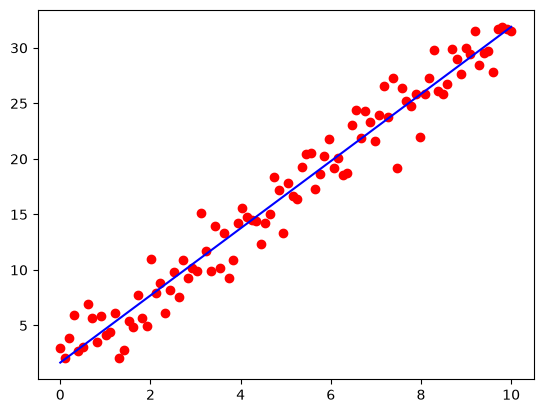

In [4]:
plt.plot(X, y, 'ro')
plt.plot(X, y_hat, 'b-')
plt.show()

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

(4128, 8)
Epoch 100/300 - Loss: 0.30928419
Epoch 200/300 - Loss: 0.28662116
Epoch 300/300 - Loss: 0.27631312
(9, 1)


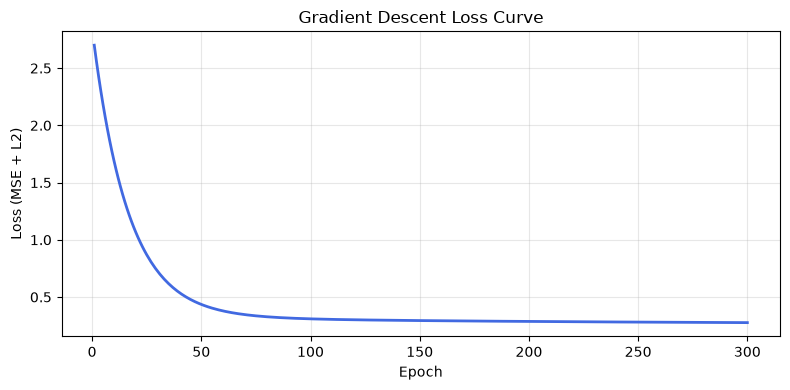

In [6]:
housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_test.shape)

model = LinearRegression(X_train, y_train, method = "gd", lr = 0.03, epochs= 300, verbose=True)
w = model.fit()
print(w.shape)
model.plot_loss()